**PROJECT 02:** Titanic Survival Prediction

This project predicts whether a passenger survived the Titanic disaster using machine learning techniques. Multiple models will be trained and compared to identify the best-performing algorithm.

This cell imports all required libraries for data manipulation, visualization, preprocessing, model building, and evaluation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

This cell loads the Titanic dataset into a Pandas DataFrame. Viewing the first few records helps us understand the available features.

In [3]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


This cell displays the total number of rows and columns present in the dataset.

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (891, 12)


This cell shows column names, data types, and missing values.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


This cell provides statistical measures such as mean, median, minimum, and maximum values.

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


This cell identifies columns that contain missing values.

In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


This graph shows how many passengers survived and how many did not survive.

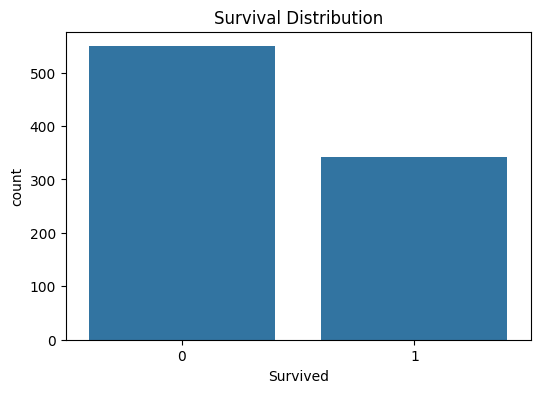

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x='Survived', data=df)

plt.title("Survival Distribution")

plt.show()

This graph compares survival rates between male and female passengers.

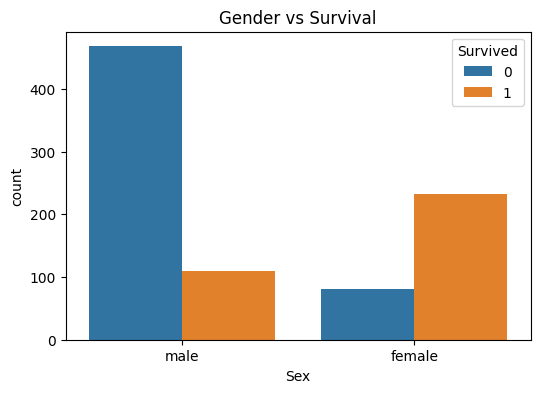

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title("Gender vs Survival")

plt.show()

This graph shows the relationship between passenger class and survival.

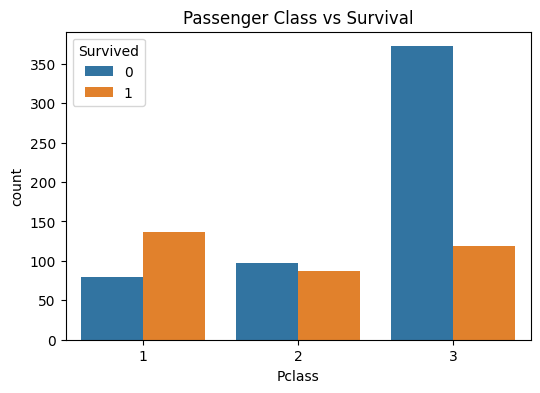

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)

plt.title("Passenger Class vs Survival")

plt.show()

This histogram shows the age distribution of Titanic passengers.

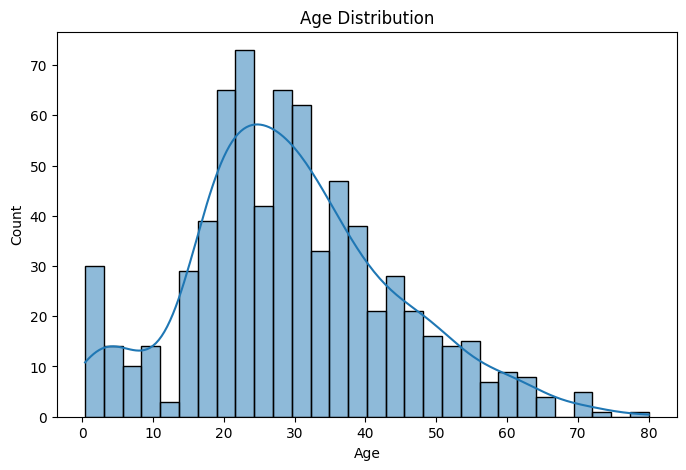

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

This heatmap shows correlations between numerical features

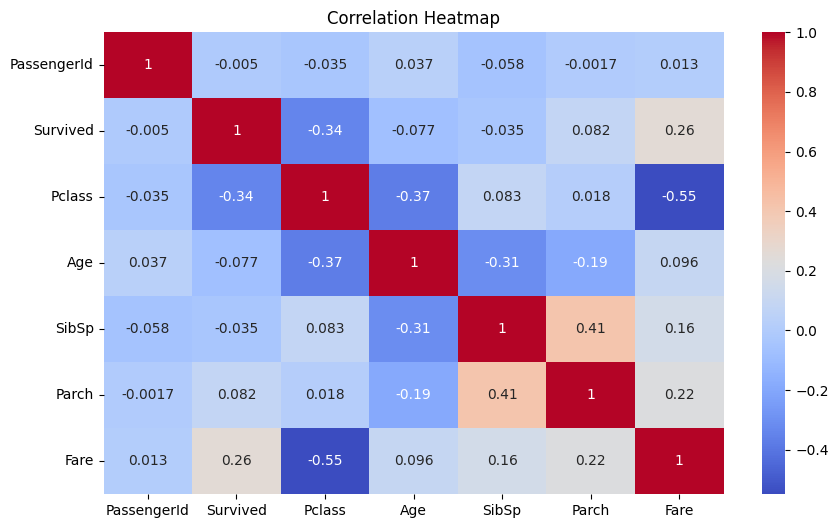

In [12]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Missing values are replaced using median and mode. Cabin is dropped because it contains too many missing values.

In [13]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

df.drop('Cabin', axis=1, inplace=True)

Categorical variables are converted into numerical form for machine learning algorithms

In [14]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])

df['Embarked'] = le.fit_transform(df['Embarked'])

Unnecessary columns are removed to improve model performance.

In [15]:
df.drop(
    ['PassengerId',
     'Name',
     'Ticket'],
    axis=1,
    inplace=True
)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


This identifies which features contribute most to survival prediction.

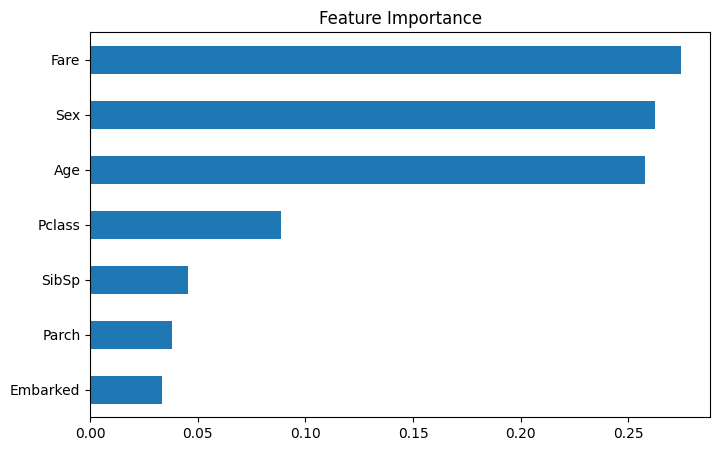

In [16]:
X_temp = df.drop('Survived', axis=1)

y_temp = df['Survived']

rf_temp = RandomForestClassifier(
    random_state=42
)

rf_temp.fit(X_temp, y_temp)

importance = pd.Series(
    rf_temp.feature_importances_,
    index=X_temp.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.show()

Separating input features from the target variable

In [17]:
X = df.drop('Survived', axis=1)

y = df['Survived']

The dataset is split into training and testing sets using an 80:20 ratio.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(712, 7)
(179, 7)


Model 1:**Logistic Regression**

Logistic Regression is a linear classification algorithm used for binary prediction.

In [19]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

Model 2: **Decision Tree**

Decision Tree creates rule-based splits to classify passengers.

In [20]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

Model 3: **Random Forest**

Random Forest combines multiple decision trees to improve prediction accuracy.

In [21]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

**Evaluation & Comparison Table**

This cell compares all three models using Accuracy, Precision, Recall, and F1 Score.

In [22]:
results = pd.DataFrame({
'Model':[
'Logistic Regression',
'Decision Tree',
'Random Forest'
],

'Accuracy':[
accuracy_score(y_test,lr_pred),
accuracy_score(y_test,dt_pred),
accuracy_score(y_test,rf_pred)
],

'Precision':[
precision_score(y_test,lr_pred),
precision_score(y_test,dt_pred),
precision_score(y_test,rf_pred)
],

'Recall':[
recall_score(y_test,lr_pred),
recall_score(y_test,dt_pred),
recall_score(y_test,rf_pred)
],

'F1 Score':[
f1_score(y_test,lr_pred),
f1_score(y_test,dt_pred),
f1_score(y_test,rf_pred)
]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.821229,0.808824,0.743243,0.774648
0,Logistic Regression,0.810056,0.785714,0.743243,0.763889
1,Decision Tree,0.782123,0.721519,0.770270,0.745098


**Best Model Analysis**

In [23]:
best_model = results.loc[
    results['Accuracy'].idxmax()
]

best_model

,2
Model,Random Forest
Accuracy,0.821229
Precision,0.808824
Recall,0.743243
F1 Score,0.774648


**Confusion Matrix**

The confusion matrix visualizes correct and incorrect predictions of the best model.

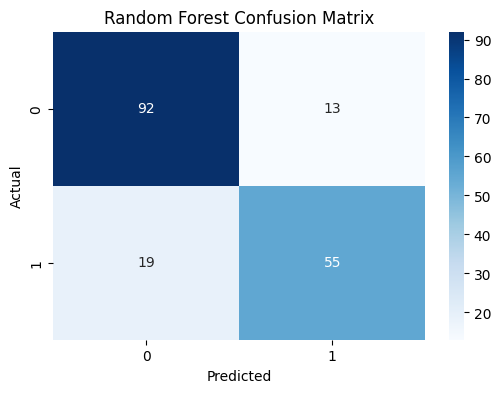

In [24]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

**Classification Report**

This report provides detailed performance metrics for the best model.

In [28]:
from sklearn.metrics import classification_report

In [29]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



Model 4: **K-Nearest Neighbors**

In [31]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train,y_train)

knn_pred = knn.predict(X_test)

Model 5: **Support Vector Machine**

In [32]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train,y_train)

svm_pred = svm.predict(X_test)

**Updated Comparison Table**

In [33]:
results = pd.DataFrame({
'Model':[
'Logistic Regression',
'Decision Tree',
'Random Forest',
'KNN',
'SVM'
],

'Accuracy':[
accuracy_score(y_test,lr_pred),
accuracy_score(y_test,dt_pred),
accuracy_score(y_test,rf_pred),
accuracy_score(y_test,knn_pred),
accuracy_score(y_test,svm_pred)
],

'Precision':[
precision_score(y_test,lr_pred),
precision_score(y_test,dt_pred),
precision_score(y_test,rf_pred),
precision_score(y_test,knn_pred),
precision_score(y_test,svm_pred)
],

'Recall':[
recall_score(y_test,lr_pred),
recall_score(y_test,dt_pred),
recall_score(y_test,rf_pred),
recall_score(y_test,knn_pred),
recall_score(y_test,svm_pred)
],

'F1 Score':[
f1_score(y_test,lr_pred),
f1_score(y_test,dt_pred),
f1_score(y_test,rf_pred),
f1_score(y_test,knn_pred),
f1_score(y_test,svm_pred)
]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.821229,0.808824,0.743243,0.774648
0,Logistic Regression,0.810056,0.785714,0.743243,0.763889
1,Decision Tree,0.782123,0.721519,0.770270,0.745098
3,KNN,0.703911,0.684211,0.527027,0.595420
4,SVM,0.659218,0.760000,0.256757,0.383838


**Survival Percentage**

In [34]:
survival_rate = (
    df['Survived'].mean()
)*100

print(
    f"Overall Survival Rate: {survival_rate:.2f}%"
)

Overall Survival Rate: 38.38%


**Feature Importance Ranking**

In [35]:
importance_df = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance_df.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
1,Sex,0.271410
5,Fare,0.265010
2,Age,0.249995
0,Pclass,0.086957
3,SibSp,0.053685
4,Parch,0.039897
6,Embarked,0.033044


**Model Accuracy Bar Chart**

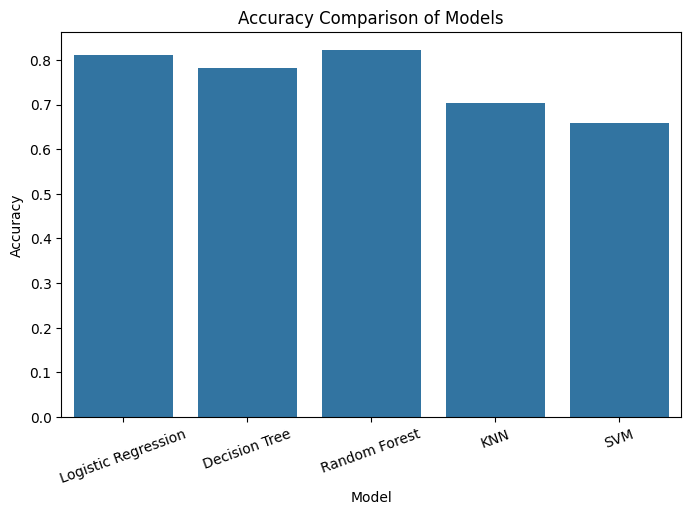

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title("Accuracy Comparison of Models")

plt.xticks(rotation=20)

plt.show()

**Cross Validation**

In [37]:
from sklearn.model_selection import cross_val_score

In [38]:
cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:")
print(cv_scores)

print(
    "Average CV Score:",
    cv_scores.mean()
)

Cross Validation Scores:
[0.77094972 0.81460674 0.86516854 0.7752809  0.82022472]
Average CV Score: 0.8092461239093591


**Correlation with Survival**

In [39]:
corr = df.corr(
    numeric_only=True
)['Survived']

print(
    corr.sort_values(
        ascending=False
    )
)

Survived    1.000000
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.064910
Embarked   -0.167675
Pclass     -0.338481
Sex        -0.543351
Name: Survived, dtype: float64


**Conclusion**

1. The Titanic dataset was cleaned and preprocessed by handling missing values and encoding categorical variables.
2. Five machine learning models were trained and evaluated using Accuracy, Precision, Recall and F1 Score.
3. Random Forest achieved the best overall performance among all models.
4. Feature importance analysis showed that Sex, Fare and Pclass were the most influential factors affecting survival.
5. Based on evaluation metrics and cross-validation results, Random Forest was selected as the final model for survival prediction.